# Preprocessing - Etape 3 (Baseline solide)

Objectif: preparer un dataset Wazuh simule pour l'entrainement ML,
avec un preprocessing stable, reproductible et dimension reduite.


## 1. Setup

### Imports

In [75]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight


### Chemins fichiers

In [76]:
DATA_PATH = Path("data/logs_simules.csv")
if not DATA_PATH.exists():
    alt = Path("../data/logs_simules.csv")
    if alt.exists():
        DATA_PATH = alt

print("Data path:", DATA_PATH)


Data path: ..\data\logs_simules.csv


### Seed

In [77]:
SEED = 42
np.random.seed(SEED)


### Options pandas

In [78]:
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 120)


## 2. Chargement du dataset

In [79]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (10000, 27)


,timestamp,agent_id,agent_name,agent_ip,os_name,os_version,os_platform,manager_name,manager_ip,location,rule_id,rule_level,rule_description,rule_groups,decoder_name,srcip,dstip,srcport,dstport,protocol,user,process,command,status,full_log,severity,attack_type
0,2025-12-27T18:31:31.877Z,3,win-01,10.10.2.15,Windows,2019.00,windows,wazuh-manager-01,10.10.0.10,EventChannel,100201,13,Malware execution suspected,"['malware', 'execution', 'attack']",windows_eventchannel,198.51.100.173,10.10.2.15,39885,80,udp,svc_backup,powershell.exe,powershell -EncodedCommand SQBFAFgAIA...,execution,Suspicious process execution: powershell.exe p...,critical,malware
1,2025-12-27T18:34:29.877Z,4,win-02,10.10.2.22,Windows,10.00,windows,wazuh-manager-01,10.10.0.10,EventChannel,100201,13,Malware execution suspected,"['malware', 'execution', 'attack']",windows_eventchannel,192.168.1.186,10.10.2.22,56751,8080,tcp,bob,powershell.exe,powershell -EncodedCommand SQBFAFgAIA...,execution,Suspicious process execution: powershell.exe p...,critical,malware
2,2025-12-27T18:24:41.877Z,4,win-02,10.10.2.22,Windows,10.00,windows,wazuh-manager-01,10.10.0.10,EventChannel,80703,3,File access normal,"['file', 'audit']",windows_eventchannel,10.10.2.22,10.10.2.22,0,0,local,alice,powershell.exe,open C:\Windows\Temp\tmp.log,NaN,File accessed by user alice: C:\Windows\Temp\t...,low,normal
3,2025-12-27T18:51:38.877Z,1,web-01,10.10.1.21,Ubuntu,22.04,linux,wazuh-manager-01,10.10.0.10,/var/log/auth.log,5712,10,SSHD brute force attempt,"['authentication_failed', 'ssh', 'attack']",sshd,203.0.113.207,10.10.1.21,46464,22,tcp,svc_backup,sshd,NaN,Failed password,Failed password for invalid user svc_backup fr...,high,bruteforce
4,2025-12-27T17:54:20.877Z,1,web-01,10.10.1.21,Ubuntu,22.04,linux,wazuh-manager-01,10.10.0.10,/var/log/auth.log,5716,3,Successful SSH login,"['authentication_success', 'ssh']",sshd,203.0.113.124,10.10.1.21,51633,22,tcp,bob,sshd,NaN,Accepted password,Accepted password for bob from 203.0.113.124 p...,low,normal


In [80]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         10000 non-null  object 
 1   agent_id          10000 non-null  int64  
 2   agent_name        10000 non-null  object 
 3   agent_ip          10000 non-null  object 
 4   os_name           10000 non-null  object 
 5   os_version        10000 non-null  float64
 6   os_platform       10000 non-null  object 
 7   manager_name      10000 non-null  object 
 8   manager_ip        10000 non-null  object 
 9   location          10000 non-null  object 
 10  rule_id           10000 non-null  int64  
 11  rule_level        10000 non-null  int64  
 12  rule_description  10000 non-null  object 
 13  rule_groups       10000 non-null  object 
 14  decoder_name      10000 non-null  object 
 15  srcip             10000 non-null  object 
 16  dstip             10000 non-null  object 

## 3. Verification des valeurs manquantes

In [81]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_count


command             3540
status              3093
timestamp              0
agent_ip               0
os_name                0
os_version             0
os_platform            0
manager_name           0
manager_ip             0
agent_id               0
agent_name             0
rule_id                0
location               0
rule_level             0
rule_description       0
srcip                  0
dstip                  0
rule_groups            0
decoder_name           0
dstport                0
srcport                0
user                   0
protocol               0
process                0
full_log               0
severity               0
attack_type            0
dtype: int64

In [82]:
missing_pct


command             35.40
status              30.93
timestamp            0.00
agent_ip             0.00
os_name              0.00
os_version           0.00
os_platform          0.00
manager_name         0.00
manager_ip           0.00
agent_id             0.00
agent_name           0.00
rule_id              0.00
location             0.00
rule_level           0.00
rule_description     0.00
srcip                0.00
dstip                0.00
rule_groups          0.00
decoder_name         0.00
dstport              0.00
srcport              0.00
user                 0.00
protocol             0.00
process              0.00
full_log             0.00
severity             0.00
attack_type          0.00
dtype: float64

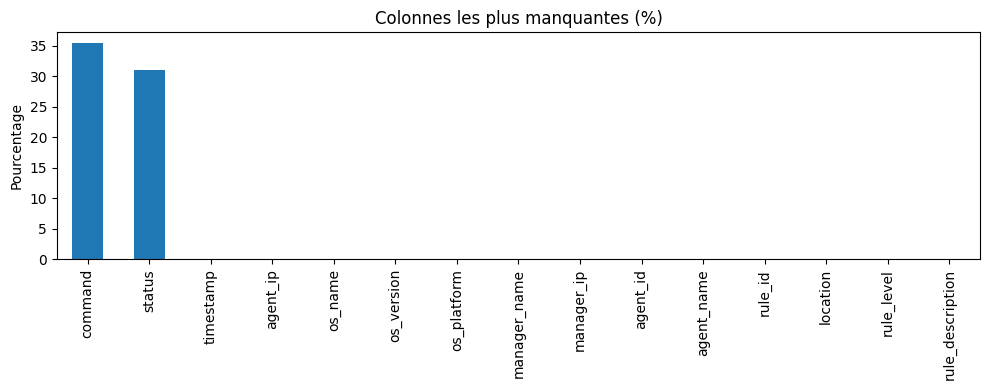

In [83]:
top_missing = missing_pct.head(15)
plt.figure(figsize=(10, 4))
top_missing.plot(kind="bar")
plt.title("Colonnes les plus manquantes (%)")
plt.ylabel("Pourcentage")
plt.tight_layout()
plt.show()


Dans des logs Wazuh, des champs peuvent etre absents selon le type d'evenement,
le decoder, ou la source. Un certain niveau de valeurs manquantes est donc normal.
L'important est de les traiter de facon coherente pour le modele.


## 4. Selection des variables pour ML

In [84]:
# Colonnes a ignorer pour une baseline stable (evite l'overfit)
# Ces champs pourront etre reactives dans une version ulterieure.
DROP_COLUMNS = [
    "timestamp",
    "agent_ip",
    "manager_ip",
    "manager_name",
    "srcip",
    "dstip",
]

DROP_COLUMNS


['timestamp', 'agent_ip', 'manager_ip', 'manager_name', 'srcip', 'dstip']

## 5. Exclusion de command et status (baseline)

Les champs command et status ont souvent un taux de valeurs manquantes eleve.
Leur contenu est heterogene selon le type de log.
Ils seront ajoutes dans une version ulterieure apres la baseline.


In [85]:
df[["command", "status"]].isna().sum()


command    3540
status     3093
dtype: int64

exclus pour baseline, trop manquants et heterogenes, ajoutes dans une version ulterieure

## 6. Separation X et y

In [86]:
X = df.drop(columns=DROP_COLUMNS + ["severity", "attack_type"], errors="ignore").copy()
# On ignore command et status dans cette baseline
X = X.drop(columns=["command", "status"], errors="ignore")

y_severity = df["severity"].copy()
y_attack_type = df["attack_type"].copy()

X.shape, y_severity.shape, y_attack_type.shape


((10000, 17), (10000,), (10000,))

## 7. Definition des colonnes par type

In [87]:
numeric_cols = []
for col in ["rule_level", "srcport", "dstport", "os_version"]:
    if col in X.columns:
        numeric_cols.append(col)

categorical_cols = []
for col in [
    "os_platform",
    "os_name",
    "location",
    "decoder_name",
    "protocol",
    "user",
    "process",
    "rule_id",
    "rule_groups",
    "agent_name",
]:
    if col in X.columns:
        categorical_cols.append(col)

text_features = []
if "full_log" in X.columns:
    text_features.append("full_log")

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)
print("Text:", text_features)


Numeric: ['rule_level', 'srcport', 'dstport', 'os_version']
Categorical: ['os_platform', 'os_name', 'location', 'decoder_name', 'protocol', 'user', 'process', 'rule_id', 'rule_groups', 'agent_name']
Text: ['full_log']


## 8. Construction du pipeline preprocessing

In [88]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5)),
    ]
)


def join_text_columns(x):
    if isinstance(x, pd.DataFrame):
        df_text = x
    else:
        df_text = pd.DataFrame(x)
    return df_text.fillna("").astype(str).agg(" ".join, axis=1)


text_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="")),
        ("join_text", FunctionTransformer(join_text_columns, validate=False)),
        (
            "tfidf",
            TfidfVectorizer(
                max_features=800,
                min_df=2,
                max_df=0.9,
                ngram_range=(1, 1),
                stop_words="english",
            ),
        ),
    ]
)

transformers = []
if numeric_cols:
    transformers.append(("num", numeric_pipeline, numeric_cols))
if categorical_cols:
    transformers.append(("cat", categorical_pipeline, categorical_cols))
if text_features:
    transformers.append(("text", text_pipeline, text_features))

preprocessor = ColumnTransformer(transformers=transformers)


## 9. Transformation finale

In [89]:
X_trans = preprocessor.fit_transform(X)
print("Shape apres preprocessing:", X_trans.shape)
print("Type X_trans:", type(X_trans))


Shape apres preprocessing: (10000, 863)
Type X_trans: <class 'scipy.sparse._csr.csr_matrix'>


## 10. Encodage des targets (label encoding)

In [90]:
le_sev = LabelEncoder()
le_atk = LabelEncoder()

df["severity_encoded"] = le_sev.fit_transform(y_severity)
df["attack_type_encoded"] = le_atk.fit_transform(y_attack_type)

print("Classes severity:", list(le_sev.classes_))
print("Classes attack_type:", list(le_atk.classes_))


Classes severity: ['critical', 'high', 'low']
Classes attack_type: ['bruteforce', 'ddos', 'malware', 'normal', 'phishing', 'privilege_escalation']


## 11. Analyse du desequilibre des classes

In [91]:
severity_counts = y_severity.value_counts()
severity_pct = y_severity.value_counts(normalize=True) * 100

pd.DataFrame({"count": severity_counts, "pct": severity_pct.round(2)})


,count,pct
severity,,
low,8000,80.0
high,1180,11.8
critical,820,8.2


In [92]:
attack_counts = y_attack_type.value_counts()
attack_pct = y_attack_type.value_counts(normalize=True) * 100

pd.DataFrame({"count": attack_counts, "pct": attack_pct.round(2)})


,count,pct
attack_type,,
normal,8000,80.00
bruteforce,480,4.80
malware,434,4.34
ddos,414,4.14
privilege_escalation,386,3.86
phishing,286,2.86


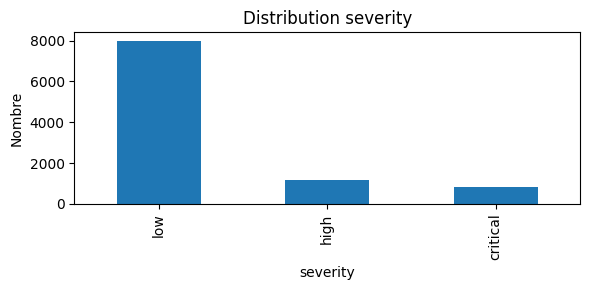

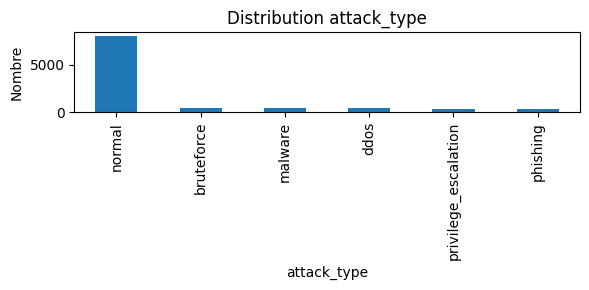

In [93]:
plt.figure(figsize=(6, 3))
severity_counts.plot(kind="bar")
plt.title("Distribution severity")
plt.ylabel("Nombre")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
attack_counts.plot(kind="bar")
plt.title("Distribution attack_type")
plt.ylabel("Nombre")
plt.tight_layout()
plt.show()


On utilisera class_weight='balanced' dans LogisticRegression ou LinearSVC
au moment du training au lieu de SMOTE, car les features sont mixtes (TF-IDF + OneHot).


In [94]:
severity_classes = np.unique(y_severity.dropna())
attack_classes = np.unique(y_attack_type.dropna())

weights_severity = compute_class_weight(
    class_weight="balanced",
    classes=severity_classes,
    y=y_severity.dropna(),
)
weights_attack_type = compute_class_weight(
    class_weight="balanced",
    classes=attack_classes,
    y=y_attack_type.dropna(),
)

weights_severity = dict(zip(severity_classes, weights_severity))
weights_attack_type = dict(zip(attack_classes, weights_attack_type))

print("weights_severity:", weights_severity)
print("weights_attack_type:", weights_attack_type)


weights_severity: {'critical': np.float64(4.065040650406504), 'high': np.float64(2.824858757062147), 'low': np.float64(0.4166666666666667)}
weights_attack_type: {'bruteforce': np.float64(3.4722222222222223), 'ddos': np.float64(4.025764895330113), 'malware': np.float64(3.8402457757296466), 'normal': np.float64(0.20833333333333334), 'phishing': np.float64(5.827505827505828), 'privilege_escalation': np.float64(4.317789291882556)}


## 12. Sanity Check

In [95]:
# Verifier NaN dans X_trans (sparse)
try:
    has_nan = np.isnan(X_trans.data).any()
except Exception:
    has_nan = np.isnan(X_trans).any()

print("NaN dans X_trans:", bool(has_nan))
print("Shape finale:", X_trans.shape)

# Contribution approximative des features
try:
    tfidf = preprocessor.named_transformers_["text"].named_steps["tfidf"]
    n_tfidf = tfidf.max_features
except Exception:
    n_tfidf = None

try:
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    n_cat = len(ohe.get_feature_names_out())
except Exception:
    n_cat = None

print("Features TF-IDF approx:", n_tfidf)
print("Features cat approx:", n_cat)

if X_trans.shape[1] < 1500:
    print("OK: dimension reduite (<1500)")
else:
    print("Attention: dimension encore elevee")


NaN dans X_trans: False
Shape finale: (10000, 863)
Features TF-IDF approx: 800
Features cat approx: 59
OK: dimension reduite (<1500)
